# Stage 11A — HOLD and Unavailable Cause Audit

This independent notebook inherits the sealed Stage 10 role registry and the completed Stage 11 v0.2 record. It audits why all five preassigned breast-ultrasound development datasets stopped at `HOLD` or `UNAVAILABLE`. It distinguishes provider transport, client endpoint, licence/provenance, label/schema, patient-grouping, duplicate/leakage, and genuine source-recoverability failures.

The notebook may read the already-authorised development records and make bounded **metadata-only** requests to official provider endpoints. It does not download images or labels, rebuild embeddings, fit a source axis, evaluate transfer edges, fit DDO2, change a dataset role, substitute a dataset, or access any locked-blind asset.

The Stage 11 record remains immutable. A repair candidate is an auditable handoff to a separate Stage 11B; it is not a retrospective Stage 11 pass and never authorises Stage 12.


In [1]:
# @title 11A-0. Mount Drive, verify sealed parents, define immutable scope, and seal the audit protocol
import hashlib
import json
import os
import re
import shutil
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ModuleNotFoundError:
    pass

TEST_MODE = bool(os.environ.get("CDO_STAGE11A_TEST_MODE") == "1" and not IN_COLAB)
DEFAULT_PROJECT_ROOT = Path("/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability") if IN_COLAB else Path("/tmp/Cross-Modal_Diagnostic_Observability")
PROJECT_ROOT = Path(os.environ.get("CDO_PROJECT_ROOT", str(DEFAULT_PROJECT_ROOT)))
CODE_ROOT = PROJECT_ROOT / "05_Code" / "Cross_Modal"
CROSS_MODAL_ROOT = PROJECT_ROOT / "06_Data_Records" / "Cross_Modal"
STAGE10_ROOT = CROSS_MODAL_ROOT / "Stage10_Preassigned_Development_And_Locked_Blind_Registry_v0.1"
STAGE11_ROOT = CROSS_MODAL_ROOT / "Stage11_Development_Extension_Acquisition_And_Source_Gates_v0.2"
STAGE11A_ROOT = CROSS_MODAL_ROOT / "Stage11A_Hold_And_Unavailable_Cause_Audit_v0.1"

PROTOCOL_ROOT = STAGE11A_ROOT / "00_Protocol"
EVIDENCE_ROOT = STAGE11A_ROOT / "01_Inherited_And_Official_Evidence"
CAUSE_ROOT = STAGE11A_ROOT / "02_Cause_Classification"
ACTION_ROOT = STAGE11A_ROOT / "03_Frozen_Remediation_Actions"
QUALITY_ROOT = STAGE11A_ROOT / "04_Independent_Validity"
RESULT_ROOT = STAGE11A_ROOT / "05_Results"
for directory in [CODE_ROOT, PROTOCOL_ROOT, EVIDENCE_ROOT, CAUSE_ROOT, ACTION_ROOT, QUALITY_ROOT, RESULT_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

NOTEBOOK_PATH = CODE_ROOT / "CrossModal_Stage11A_Hold_And_Unavailable_Cause_Audit_v0.1.ipynb"
STAGE10_PROTOCOL_PATH = STAGE10_ROOT / "00_Protocol" / "Stage10_Acquisition_Role_Registry_Protocol_Seal_v0.1.json"
STAGE10_ROLE_PATH = STAGE10_ROOT / "01_Role_Registry" / "Stage10_Frozen_Dataset_Acquisition_Role_Registry_v0.1.csv"
STAGE10_FINAL_PATH = STAGE10_ROOT / "05_Results" / "Stage10_Preassigned_Role_Registry_Complete_v0.1.json"
STAGE11_PROTOCOL_PATH = STAGE11_ROOT / "00_Protocol" / "Stage11_Development_Acquisition_And_Source_Gate_Protocol_Seal_v0.2.json"
STAGE11_ACQUISITION_PATH = STAGE11_ROOT / "01_Official_Acquisition" / "Stage11_Development_Dataset_Acquisition_Status_v0.2.csv"
STAGE11_REQUEST_PATH = STAGE11_ROOT / "01_Official_Acquisition" / "Stage11_Development_Only_Request_Audit_v0.2.csv"
STAGE11_CHECKSUM_PATH = STAGE11_ROOT / "01_Official_Acquisition" / "Stage11_Official_File_Checksum_Ledger_v0.2.csv"
STAGE11_BUSBRA_MANIFEST_PATH = STAGE11_ROOT / "02_Harmonised_Manifests" / "BUS_BRA_2024_Harmonised_Development_Manifest_v0.2.csv"
STAGE11_SOURCE_PATH = STAGE11_ROOT / "04_Frozen_Source_Axes" / "Stage11_Source_Recoverability_Summary_v0.2.csv"
STAGE11_LABEL_AUDIT_PATH = STAGE11_ROOT / "05_Quality_And_Leakage_Audits" / "Stage11_Label_Grouping_And_Eligibility_Audit_v0.2.csv"
STAGE11_VALIDITY_PATH = STAGE11_ROOT / "05_Quality_And_Leakage_Audits" / "Stage11_Independent_Validity_Checks_v0.2.csv"
STAGE11_OUTPUT_MANIFEST_PATH = STAGE11_ROOT / "06_Results" / "Stage11_Output_Integrity_Manifest_v0.2.csv"
STAGE11_FINAL_PATH = STAGE11_ROOT / "06_Results" / "Stage11_Development_Acquisition_And_Source_Gates_Complete_v0.2.json"

PROTOCOL_SEAL_PATH = PROTOCOL_ROOT / "Stage11A_Hold_Cause_Audit_Protocol_Seal_v0.1.json"
PARENT_COMMITMENT_PATH = PROTOCOL_ROOT / "Stage11A_Parent_Input_Commitment_v0.1.csv"
INHERITED_STATUS_PATH = EVIDENCE_ROOT / "Stage11A_Inherited_Stage11_Status_v0.1.csv"
PARENT_FILE_AUDIT_PATH = EVIDENCE_ROOT / "Stage11A_Parent_File_Integrity_Audit_v0.1.csv"
PROBE_LOG_PATH = EVIDENCE_ROOT / "Stage11A_Official_Metadata_Probe_Log_v0.1.csv"
BUSBRA_GROUPING_PATH = EVIDENCE_ROOT / "Stage11A_BUS_BRA_Patient_Grouping_Consistency_Audit_v0.1.csv"
CAUSE_CLASSIFICATION_PATH = CAUSE_ROOT / "Stage11A_Dataset_Hold_Cause_Classification_v0.1.csv"
GATE_ATTRIBUTION_PATH = CAUSE_ROOT / "Stage11A_Gate_Attribution_v0.1.csv"
ACTION_REGISTRY_PATH = ACTION_ROOT / "Stage11A_Frozen_Remediation_Action_Registry_v0.1.csv"
VALIDITY_PATH = QUALITY_ROOT / "Stage11A_Independent_Validity_Checks_v0.1.csv"
REPORT_PATH = RESULT_ROOT / "Stage11A_Hold_And_Unavailable_Cause_Audit_Report_v0.1.md"
FIGURE_PATH = RESULT_ROOT / "Stage11A_Hold_Cause_Attribution_v0.1.png"
OUTPUT_MANIFEST_PATH = RESULT_ROOT / "Stage11A_Output_Integrity_Manifest_v0.1.csv"
RUNTIME_STATE_PATH = RESULT_ROOT / "Stage11A_Runtime_State_v0.1.json"
FINAL_RECORD_PATH = RESULT_ROOT / "Stage11A_Hold_And_Unavailable_Cause_Audit_Complete_v0.1.json"

EXPECTED_STAGE10_FINAL_HASH = "6438434cb41607ad97b1b4a2fab07b143969ce7f551b87b5c2a23afbe67ccccf"
EXPECTED_STAGE10_PROTOCOL_SEAL = "305c715cd95c72b7e54cfd241891080ddd6838e4428c6bd5acdf7b4264c96f31"
EXPECTED_ROLE_REGISTRY_HASH = "cc0b56178eecee123d8c6fa99824018b18aae79679c6620edc7e5ebcc9018bc3"
EXPECTED_STAGE11_FINAL_HASH = "bc330e4389c36729427ca07c3ea1fb0993c5c3bc2126dcbfc2ca079e1cbb8889"
EXPECTED_STAGE11_PROTOCOL_SEAL = "fc96bd4f61b41c0f64e5a24d8a270487acb25ad7c77d5b6865e9d9f4af59bbcd"
EXPECTED_STAGE11_SOURCE_HASH = "2b907cc8ebbef7c6d3fc206b7c0a3067ad3d503594f2323d9f19f2a2c3a91af6"
MAXIMUM_NEW_STAGE11A_BYTES = 20 * 1024 * 1024

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def sha256_bytes(raw):
    return hashlib.sha256(raw).hexdigest()

def sha256_file(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            block = handle.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()

def sha256_json(payload):
    raw = json.dumps(payload, sort_keys=True, separators=(",", ":"), ensure_ascii=False).encode("utf-8")
    return sha256_bytes(raw)

def canonical_csv_text(frame):
    return frame.to_csv(index=False, lineterminator="\n", float_format="%.12g")

def atomic_text(path, text):
    path = Path(path)
    temporary = Path(str(path) + ".tmp")
    temporary.write_text(text, encoding="utf-8")
    os.replace(temporary, path)

def atomic_json(path, payload):
    atomic_text(path, json.dumps(payload, indent=2, ensure_ascii=False) + "\n")

def write_progress_csv(path, frame):
    text = canonical_csv_text(frame)
    if FINAL_RECORD_PATH.is_file():
        assert Path(path).is_file() and Path(path).read_text(encoding="utf-8") == text
    else:
        atomic_text(path, text)

def write_immutable_text(path, text):
    path = Path(path)
    if path.is_file():
        assert path.read_text(encoding="utf-8") == text, f"Existing immutable output differs: {path}"
    else:
        path.write_text(text, encoding="utf-8")

def write_immutable_csv(path, frame):
    write_immutable_text(path, canonical_csv_text(frame))

def write_immutable_json(path, payload):
    write_immutable_text(path, json.dumps(payload, indent=2, ensure_ascii=False) + "\n")

def verify_self_hashed_json(path, hash_field, expected=None):
    payload = json.loads(Path(path).read_text(encoding="utf-8"))
    claim = payload.get(hash_field)
    without_claim = dict(payload)
    without_claim.pop(hash_field, None)
    assert claim == sha256_json(without_claim), f"Self-hash mismatch: {path}"
    if expected is not None:
        assert claim == expected, f"Unexpected {hash_field}: {path}"
    return payload

def normalised_notebook_source_sha256(path):
    notebook = json.loads(Path(path).read_text(encoding="utf-8"))
    payload = []
    for cell in notebook.get("cells", []):
        if cell.get("cell_type") not in {"code", "markdown"}:
            continue
        source = cell.get("source", [])
        source = "".join(source) if isinstance(source, list) else str(source)
        payload.append({"cell_type": cell["cell_type"], "source": source.replace("\r\n", "\n")})
    return sha256_json(payload)

required_parent_inputs = [
    STAGE10_PROTOCOL_PATH, STAGE10_ROLE_PATH, STAGE10_FINAL_PATH,
    STAGE11_PROTOCOL_PATH, STAGE11_ACQUISITION_PATH, STAGE11_REQUEST_PATH,
    STAGE11_CHECKSUM_PATH, STAGE11_BUSBRA_MANIFEST_PATH, STAGE11_SOURCE_PATH,
    STAGE11_LABEL_AUDIT_PATH, STAGE11_VALIDITY_PATH, STAGE11_OUTPUT_MANIFEST_PATH, STAGE11_FINAL_PATH,
]
assert NOTEBOOK_PATH.is_file(), f"Open this notebook from its frozen Drive location: {NOTEBOOK_PATH}"
assert all(path.is_file() for path in required_parent_inputs), "A required Stage 10/11 parent input is missing; do not substitute a similarly named file."

stage10_final = verify_self_hashed_json(STAGE10_FINAL_PATH, "final_record_sha256", EXPECTED_STAGE10_FINAL_HASH)
stage10_protocol = verify_self_hashed_json(STAGE10_PROTOCOL_PATH, "seal_sha256", EXPECTED_STAGE10_PROTOCOL_SEAL)
stage11_final = verify_self_hashed_json(STAGE11_FINAL_PATH, "final_record_sha256", EXPECTED_STAGE11_FINAL_HASH)
stage11_protocol = verify_self_hashed_json(STAGE11_PROTOCOL_PATH, "seal_sha256", EXPECTED_STAGE11_PROTOCOL_SEAL)
assert sha256_file(STAGE10_ROLE_PATH) == EXPECTED_ROLE_REGISTRY_HASH
assert sha256_file(STAGE11_SOURCE_PATH) == EXPECTED_STAGE11_SOURCE_HASH
assert stage11_final["decision"] == "COMPLETE_ACQUISITION_AUDIT_NO_RECOVERABLE_DEVELOPMENT_SOURCE_HOLD_STAGE12_AND_DDO2_FIT"
assert stage11_final["recoverable_source_count"] == 0
assert stage11_final["locked_blind_assets_touched"] is False
assert stage11_final["cross_domain_edges_evaluated"] is False
assert stage11_final["ddo2_coefficients_fitted"] is False
assert stage11_final["blind_validation_performed"] is False

role_registry = pd.read_csv(STAGE10_ROLE_PATH)
development_registry = role_registry[role_registry["role_frozen_before_label_access"].eq("DEVELOPMENT_EXTENSION")].sort_values("acquisition_priority").copy()
blind_registry = role_registry[role_registry["role_frozen_before_label_access"].eq("LOCKED_BLIND_TEST")].copy()
AUTHORISED_DATASETS = tuple(development_registry["dataset_id"].astype(str))
PROHIBITED_DATASETS = tuple(blind_registry["dataset_id"].astype(str))
assert len(AUTHORISED_DATASETS) == 5 and len(PROHIBITED_DATASETS) == 3
assert list(AUTHORISED_DATASETS) == list(stage11_final["authorised_development_datasets"])
assert set(PROHIBITED_DATASETS) == set(stage11_final["locked_blind_datasets"])
assert set(AUTHORISED_DATASETS).isdisjoint(PROHIBITED_DATASETS)

REPLAY_MODE = FINAL_RECORD_PATH.is_file()
notebook_source_hash = normalised_notebook_source_sha256(NOTEBOOK_PATH)
analysis_spec = {
    "scope": "audit Stage 11 HOLD/UNAVAILABLE causes for the five preassigned development datasets only",
    "cause_taxonomy": [
        "CLIENT_ENDPOINT_OR_REQUEST_ROUTE", "PROVIDER_TRANSPORT_OR_SERVICE", "LICENCE_OR_PROVENANCE_RECONCILIATION",
        "LABEL_OR_SCHEMA_INCOMPATIBILITY", "PATIENT_GROUPING_UNPROVEN", "DUPLICATE_OR_LEAKAGE_RISK", "SOURCE_RECOVERABILITY_PERFORMANCE",
    ],
    "performance_attribution_rule": "a source-recoverability performance failure requires an actually fitted frozen source axis and both recorded OOF/held-out gate evidence; absence of an axis is never a performance failure",
    "official_metadata_only": "bounded GET requests to official provider landing or public dataset metadata endpoints; no image/archive/label download",
    "BUS_BRA_grouping_rule_status": "numeric filename-prefix reconciliation may be recorded only as a release-consistent candidate; Stage 11A cannot promote it to proven patient identity",
    "repair_boundary": "repair actions remain within the existing DEVELOPMENT_EXTENSION roles and require a separate Stage 11B; no substitution or role reassignment",
    "method_boundary": "no embedding rebuild, source-axis fit, transfer edge, target refit, threshold tuning, DDO2 fit, Stage 12, or blind validation",
    "locked_blind_firewall": "no locked-blind endpoint, metadata, image, label, archive, prediction, or result request",
}
if PROTOCOL_SEAL_PATH.is_file():
    protocol_seal = verify_self_hashed_json(PROTOCOL_SEAL_PATH, "seal_sha256")
    assert protocol_seal["parent_stage11_final_record_sha256"] == EXPECTED_STAGE11_FINAL_HASH
    assert protocol_seal["analysis_spec_sha256"] == sha256_json(analysis_spec)
    assert protocol_seal["notebook_source_sha256"] == notebook_source_hash
else:
    protocol_seal = {
        "stage": "Stage11A",
        "protocol_version": "0.1",
        "decision": "SEAL_HOLD_AND_UNAVAILABLE_CAUSE_AUDIT_PROTOCOL",
        "parent_stage10_final_record_sha256": EXPECTED_STAGE10_FINAL_HASH,
        "parent_stage10_protocol_seal_sha256": EXPECTED_STAGE10_PROTOCOL_SEAL,
        "parent_role_registry_sha256": EXPECTED_ROLE_REGISTRY_HASH,
        "parent_stage11_final_record_sha256": EXPECTED_STAGE11_FINAL_HASH,
        "parent_stage11_protocol_seal_sha256": EXPECTED_STAGE11_PROTOCOL_SEAL,
        "notebook_source_sha256": notebook_source_hash,
        "authorised_development_datasets": list(AUTHORISED_DATASETS),
        "prohibited_locked_blind_dataset_count": len(PROHIBITED_DATASETS),
        "analysis_spec": analysis_spec,
        "analysis_spec_sha256": sha256_json(analysis_spec),
        "maximum_new_stage11a_bytes": MAXIMUM_NEW_STAGE11A_BYTES,
        "sealed_utc": utc_now(),
    }
    protocol_seal["seal_sha256"] = sha256_json(protocol_seal)
    write_immutable_json(PROTOCOL_SEAL_PATH, protocol_seal)

print("================ STAGE 11A HOLD-CAUSE AUDIT PREFLIGHT ================")
print("Stage 10 / Stage 11 final records verified:", EXPECTED_STAGE10_FINAL_HASH, "/", EXPECTED_STAGE11_FINAL_HASH)
print("Stage 11A protocol seal:", protocol_seal["seal_sha256"])
print("Authorised development / prohibited blind datasets:", len(AUTHORISED_DATASETS), "/", len(PROHIBITED_DATASETS))
print("Replay mode / locked-blind assets touched:", REPLAY_MODE, "/", False)


Mounted at /content/drive
================ STAGE 11A HOLD-CAUSE AUDIT PREFLIGHT ================
Stage 10 / Stage 11 final records verified: 6438434cb41607ad97b1b4a2fab07b143969ce7f551b87b5c2a23afbe67ccccf / bc330e4389c36729427ca07c3ea1fb0993c5c3bc2126dcbfc2ca079e1cbb8889
Stage 11A protocol seal: e8196fcdb9c05c5b04e9bbf8ac3b520991e51114d684ef3484b36c5fbad1cd44
Authorised development / prohibited blind datasets: 5 / 3
Replay mode / locked-blind assets touched: False / False


In [2]:
# @title 11A-1. Load the five-domain Stage 11 evidence and prove whether a performance gate was ever reached
acquisition = pd.read_csv(STAGE11_ACQUISITION_PATH).sort_values("acquisition_priority").reset_index(drop=True)
request_audit = pd.read_csv(STAGE11_REQUEST_PATH)
checksum_ledger = pd.read_csv(STAGE11_CHECKSUM_PATH)
label_audit = pd.read_csv(STAGE11_LABEL_AUDIT_PATH)
source_summary = pd.read_csv(STAGE11_SOURCE_PATH)
stage11_validity = pd.read_csv(STAGE11_VALIDITY_PATH)

assert acquisition["dataset_id"].astype(str).tolist() == list(AUTHORISED_DATASETS)
assert set(label_audit["dataset_id"].astype(str)) == set(AUTHORISED_DATASETS)
assert set(source_summary["source"].astype(str)) == set(AUTHORISED_DATASETS)
assert not source_summary["recoverable"].astype(str).str.lower().eq("true").any()

source_for_merge = source_summary.rename(columns={"source": "dataset_id"}).copy()
source_for_merge["performance_gate_reached"] = (
    pd.to_numeric(source_for_merge["development_units"], errors="coerce").fillna(0).gt(0)
    & pd.to_numeric(source_for_merge["validation_units"], errors="coerce").fillna(0).gt(0)
    & pd.to_numeric(source_for_merge["development_oof_auc"], errors="coerce").notna()
    & pd.to_numeric(source_for_merge["validation_auc"], errors="coerce").notna()
)
source_for_merge["true_source_performance_failure_observed"] = (
    source_for_merge["performance_gate_reached"]
    & ~source_for_merge["recoverable"].astype(str).str.lower().eq("true")
)

inherited_status = acquisition.merge(
    label_audit[["dataset_id", "eligible_images", "patient_groups", "negative_images", "positive_images", "patient_grouping_proven", "source_schema_eligible", "hold_or_error_reason"]],
    on="dataset_id", how="left", validate="one_to_one",
).merge(
    source_for_merge[["dataset_id", "development_units", "validation_units", "development_oof_auc", "validation_auc", "recoverable", "failure_reason", "performance_gate_reached", "true_source_performance_failure_observed"]],
    on="dataset_id", how="left", validate="one_to_one",
)
assert len(inherited_status) == 5
assert not inherited_status["performance_gate_reached"].any()
assert not inherited_status["true_source_performance_failure_observed"].any()

parent_files = required_parent_inputs.copy()
parent_file_audit = pd.DataFrame([
    {
        "relative_path": str(path.relative_to(PROJECT_ROOT)),
        "size_bytes": path.stat().st_size,
        "sha256": sha256_file(path),
    }
    for path in parent_files
])
parent_commitment = pd.DataFrame([
    {"commitment": "stage10_final_record", "value": EXPECTED_STAGE10_FINAL_HASH},
    {"commitment": "stage10_protocol_seal", "value": EXPECTED_STAGE10_PROTOCOL_SEAL},
    {"commitment": "stage10_role_registry", "value": EXPECTED_ROLE_REGISTRY_HASH},
    {"commitment": "stage11_final_record", "value": EXPECTED_STAGE11_FINAL_HASH},
    {"commitment": "stage11_protocol_seal", "value": EXPECTED_STAGE11_PROTOCOL_SEAL},
    {"commitment": "stage11_source_summary", "value": EXPECTED_STAGE11_SOURCE_HASH},
    {"commitment": "authorised_development_dataset_count", "value": "5"},
    {"commitment": "prohibited_locked_blind_dataset_count", "value": "3"},
    {"commitment": "stage11_true_model_failures_observed", "value": "0"},
])

write_progress_csv(PARENT_COMMITMENT_PATH, parent_commitment)
write_progress_csv(PARENT_FILE_AUDIT_PATH, parent_file_audit)
write_progress_csv(INHERITED_STATUS_PATH, inherited_status)

display(inherited_status[[
    "dataset_id", "acquisition_status", "eligible_images", "patient_grouping_proven",
    "performance_gate_reached", "true_source_performance_failure_observed", "failure_reason"
]])
print("Performance gates reached / true model failures:", int(inherited_status["performance_gate_reached"].sum()), "/", int(inherited_status["true_source_performance_failure_observed"].sum()))


,dataset_id,acquisition_status,eligible_images,patient_grouping_proven,performance_gate_reached,true_source_performance_failure_observed,failure_reason
0,BUS_BRA_2024,ACQUIRED_HOLD_PATIENT_GROUPING_NOT_PROVEN,1875,False,False,False,ACQUIRED_HOLD_PATIENT_GROUPING_NOT_PROVEN
1,BUSI_WHU_2025_V3,UNAVAILABLE,0,False,False,False,UNAVAILABLE
2,BREAST_LESIONS_USG_2024,HOLD_PROVIDER_TRANSPORT,0,False,False,False,HOLD_PROVIDER_TRANSPORT
3,BUS_UCLM_2025_V3,UNAVAILABLE,0,False,False,False,UNAVAILABLE
4,RODRIGUES_BUI_2017,UNAVAILABLE,0,False,False,False,UNAVAILABLE


Performance gates reached / true model failures: 0 / 0


In [3]:
# @title 11A-2. Probe only official development metadata routes; never download an image, archive, or label
import requests

ALLOWED_METADATA_HOSTS = {
    "api.mendeley.com", "data.mendeley.com",
    "www.cancerimagingarchive.net", "services.cancerimagingarchive.net", "nbia.cancerimagingarchive.net",
}
MENDELEY_VERSIONS = {
    "BUSI_WHU_2025_V3": ("k6cpmwybk3", 3),
    "BUS_UCLM_2025_V3": ("7fvgj4jsp7", 3),
    "RODRIGUES_BUI_2017": ("wmy84gzngw", 1),
}
TCIA_DATASET = "BREAST_LESIONS_USG_2024"
HEADERS = {
    "User-Agent": "CrossModalDiagnosticObservability-Stage11A/0.1 (metadata-only research audit)",
    "Accept": "application/vnd.mendeley-dataset.1+json, application/json, text/html;q=0.8",
}

probe_rows = []

def safe_text_type(response):
    content_type = str(response.headers.get("content-type", "")).lower()
    prefix = response.content[:512].lstrip().lower()
    if "json" in content_type or prefix.startswith((b"{", b"[")):
        return "JSON_CANDIDATE"
    if "html" in content_type or prefix.startswith((b"<!doctype html", b"<html")):
        return "HTML"
    if not response.content:
        return "EMPTY"
    return "OTHER"

def fixture_response(dataset_id, probe_kind, url):
    if probe_kind == "MENDELEY_PUBLIC_DATASET_API":
        licences = {"BUSI_WHU_2025_V3": "CC BY 4.0", "BUS_UCLM_2025_V3": "CC BY 4.0", "RODRIGUES_BUI_2017": "CC BY 4.0"}
        return {
            "dataset_id": dataset_id, "probe_kind": probe_kind, "url": url, "host": urlparse(url).hostname,
            "status_code": 200, "response_type": "JSON", "json_valid": True, "body_bytes": 512,
            "body_sha256": sha256_bytes((dataset_id + probe_kind).encode()), "files_count": 1,
            "observed_version": MENDELEY_VERSIONS[dataset_id][1], "observed_license": licences[dataset_id],
            "dataset_name_present": True, "provider_route_live": True, "error_class": "",
        }
    if probe_kind == "MENDELEY_PUBLIC_LANDING":
        return {
            "dataset_id": dataset_id, "probe_kind": probe_kind, "url": url, "host": urlparse(url).hostname,
            "status_code": 200, "response_type": "HTML", "json_valid": False, "body_bytes": 1024,
            "body_sha256": sha256_bytes((dataset_id + probe_kind).encode()), "files_count": np.nan,
            "observed_version": MENDELEY_VERSIONS[dataset_id][1], "observed_license": "",
            "dataset_name_present": True, "provider_route_live": True, "error_class": "",
        }
    if probe_kind == "TCIA_COLLECTION_LANDING":
        return {
            "dataset_id": dataset_id, "probe_kind": probe_kind, "url": url, "host": urlparse(url).hostname,
            "status_code": 200, "response_type": "HTML", "json_valid": False, "body_bytes": 2048,
            "body_sha256": sha256_bytes((dataset_id + probe_kind).encode()), "files_count": np.nan,
            "observed_version": "", "observed_license": "", "dataset_name_present": True,
            "provider_route_live": True, "error_class": "",
        }
    return {
        "dataset_id": dataset_id, "probe_kind": probe_kind, "url": url, "host": urlparse(url).hostname,
        "status_code": 200, "response_type": "EMPTY", "json_valid": False, "body_bytes": 0,
        "body_sha256": sha256_bytes(b""), "files_count": 0, "observed_version": "",
        "observed_license": "", "dataset_name_present": False, "provider_route_live": False,
        "error_class": "NON_JSON_OR_EMPTY",
    }

def metadata_probe(dataset_id, probe_kind, url, expect_json=False):
    assert dataset_id in AUTHORISED_DATASETS
    host = (urlparse(url).hostname or "").lower()
    assert host in ALLOWED_METADATA_HOSTS, f"Non-whitelisted metadata host: {host}"
    assert not any(str(token).lower() in url.lower() for token in PROHIBITED_DATASETS), "Locked-blind token found in request URL"
    if TEST_MODE:
        row = fixture_response(dataset_id, probe_kind, url)
        probe_rows.append(row)
        return row
    try:
        response = requests.get(url, headers=HEADERS, timeout=(10, 30), allow_redirects=True)
        final_host = (urlparse(response.url).hostname or "").lower()
        response_type = safe_text_type(response)
        payload = None
        json_valid = False
        if response_type == "JSON_CANDIDATE":
            try:
                payload = response.json()
                json_valid = True
                response_type = "JSON"
            except Exception:
                response_type = "MALFORMED_JSON"
        files_count = np.nan
        observed_version = ""
        observed_license = ""
        dataset_name_present = False
        if isinstance(payload, dict):
            files = payload.get("files")
            files_count = len(files) if isinstance(files, list) else 0
            observed_version = payload.get("version", "")
            licence = payload.get("data_licence") or payload.get("license") or {}
            if isinstance(licence, dict):
                observed_license = licence.get("short_name") or licence.get("name") or ""
            elif isinstance(licence, str):
                observed_license = licence
            dataset_name_present = bool(payload.get("name") or payload.get("title"))
        elif isinstance(payload, list):
            files_count = len(payload)
            dataset_name_present = len(payload) > 0
        elif response_type == "HTML":
            dataset_name_present = any(token.lower() in response.text.lower() for token in [dataset_id, "breast", "ultrasound"])
        provider_route_live = bool(response.status_code == 200 and ((json_valid and (not expect_json or files_count != 0)) or (not expect_json and response_type == "HTML")))
        error_class = ""
        if response.status_code >= 400:
            error_class = f"HTTP_{response.status_code}"
        elif expect_json and not json_valid:
            error_class = "NON_JSON_OR_EMPTY"
        elif expect_json and isinstance(files_count, (int, np.integer)) and files_count == 0:
            error_class = "JSON_WITHOUT_FILES_OR_SERIES"
        row = {
            "dataset_id": dataset_id, "probe_kind": probe_kind, "url": url, "host": host,
            "resolved_host": final_host, "status_code": int(response.status_code), "response_type": response_type,
            "json_valid": bool(json_valid), "body_bytes": len(response.content), "body_sha256": sha256_bytes(response.content),
            "files_count": files_count, "observed_version": observed_version, "observed_license": observed_license,
            "dataset_name_present": bool(dataset_name_present), "provider_route_live": bool(provider_route_live),
            "error_class": error_class,
        }
    except requests.RequestException as exc:
        row = {
            "dataset_id": dataset_id, "probe_kind": probe_kind, "url": url, "host": host, "resolved_host": "",
            "status_code": -1, "response_type": "REQUEST_ERROR", "json_valid": False, "body_bytes": 0,
            "body_sha256": "", "files_count": np.nan, "observed_version": "", "observed_license": "",
            "dataset_name_present": False, "provider_route_live": False, "error_class": type(exc).__name__,
        }
    probe_rows.append(row)
    return row

if not REPLAY_MODE:
    for dataset_id, (mendeley_id, version) in MENDELEY_VERSIONS.items():
        metadata_probe(dataset_id, "MENDELEY_PUBLIC_DATASET_API", f"https://api.mendeley.com/datasets/{mendeley_id}?version={version}", expect_json=True)
        metadata_probe(dataset_id, "MENDELEY_PUBLIC_LANDING", f"https://data.mendeley.com/datasets/{mendeley_id}/{version}", expect_json=False)

    metadata_probe(TCIA_DATASET, "TCIA_COLLECTION_LANDING", "https://www.cancerimagingarchive.net/collection/breast-lesions-usg/", expect_json=False)
    metadata_probe(TCIA_DATASET, "TCIA_NBIA_INHERITED_ROUTE", "https://services.cancerimagingarchive.net/nbia-api/services/v1/getSeries?Collection=Breast-Lesions-USG&format=json", expect_json=True)
    metadata_probe(TCIA_DATASET, "TCIA_NBIA_ALTERNATE_OFFICIAL_HOST", "https://nbia.cancerimagingarchive.net/nbia-api/services/v1/getSeries?Collection=Breast-Lesions-USG&format=json", expect_json=True)
    probe_log = pd.DataFrame(probe_rows)
    write_progress_csv(PROBE_LOG_PATH, probe_log)
else:
    probe_log = pd.read_csv(PROBE_LOG_PATH)

assert set(probe_log["dataset_id"].astype(str)).issubset(AUTHORISED_DATASETS)
assert set(probe_log["host"].astype(str)).issubset(ALLOWED_METADATA_HOSTS)
assert not probe_log["url"].astype(str).apply(lambda url: any(token.lower() in url.lower() for token in PROHIBITED_DATASETS)).any()
display(probe_log[["dataset_id", "probe_kind", "status_code", "response_type", "files_count", "observed_license", "provider_route_live", "error_class"]])


,dataset_id,probe_kind,status_code,response_type,files_count,observed_license,provider_route_live,error_class
0,BUSI_WHU_2025_V3,MENDELEY_PUBLIC_DATASET_API,403,HTML,NaN,,False,HTTP_403
1,BUSI_WHU_2025_V3,MENDELEY_PUBLIC_LANDING,403,HTML,NaN,,False,HTTP_403
2,BUS_UCLM_2025_V3,MENDELEY_PUBLIC_DATASET_API,403,HTML,NaN,,False,HTTP_403
3,BUS_UCLM_2025_V3,MENDELEY_PUBLIC_LANDING,403,HTML,NaN,,False,HTTP_403
4,RODRIGUES_BUI_2017,MENDELEY_PUBLIC_DATASET_API,403,HTML,NaN,,False,HTTP_403
5,RODRIGUES_BUI_2017,MENDELEY_PUBLIC_LANDING,403,HTML,NaN,,False,HTTP_403
6,BREAST_LESIONS_USG_2024,TCIA_COLLECTION_LANDING,200,HTML,NaN,,True,
7,BREAST_LESIONS_USG_2024,TCIA_NBIA_INHERITED_ROUTE,200,EMPTY,NaN,,False,NON_JSON_OR_EMPTY
8,BREAST_LESIONS_USG_2024,TCIA_NBIA_ALTERNATE_OFFICIAL_HOST,200,EMPTY,NaN,,False,NON_JSON_OR_EMPTY


In [4]:
# @title 11A-3. Reconcile BUS-BRA image names to the official patient count without promoting an inferred ID
busbra_manifest = pd.read_csv(STAGE11_BUSBRA_MANIFEST_PATH)
busbra_registry = development_registry[development_registry["dataset_id"].eq("BUS_BRA_2024")].iloc[0]
official_expected_patients = int(busbra_registry["expected_patients"])
official_expected_images = int(busbra_registry["expected_images_or_scans"])

source_members = busbra_manifest["source_member"].astype(str)
candidate_patient_number = source_members.str.extract(r"(?i)bus_(\d+)-[lrs]\.(?:png|jpg|jpeg)$", expand=False)
candidate_coverage = float(candidate_patient_number.notna().mean())
candidate_groups = candidate_patient_number.dropna().nunique()
image_level_groups = busbra_manifest["group_id"].astype(str).nunique()

group_label_counts = (
    pd.DataFrame({"candidate_patient_number": candidate_patient_number, "label": busbra_manifest["label"]})
    .dropna(subset=["candidate_patient_number"])
    .groupby("candidate_patient_number")["label"].nunique()
)
mixed_label_candidate_groups = int(group_label_counts.gt(1).sum())
images_per_candidate_group = candidate_patient_number.value_counts(dropna=True)
multi_image_candidate_groups = int(images_per_candidate_group.gt(1).sum())
maximum_images_per_candidate_group = int(images_per_candidate_group.max())
candidate_rule_consistent = bool(
    len(busbra_manifest) == official_expected_images
    and candidate_coverage == 1.0
    and candidate_groups == official_expected_patients
    and mixed_label_candidate_groups == 0
    and busbra_manifest["unit_id"].astype(str).is_unique
)

busbra_grouping_audit = pd.DataFrame([{
    "dataset_id": "BUS_BRA_2024",
    "official_release_url": "https://zenodo.org/records/8231412",
    "official_expected_images": official_expected_images,
    "official_expected_patients": official_expected_patients,
    "manifest_rows": len(busbra_manifest),
    "current_manifest_group_count": image_level_groups,
    "candidate_group_rule": "numeric prefix in official member basename bus_<number>-[l|r|s].png",
    "candidate_rule_row_coverage": candidate_coverage,
    "candidate_group_count": int(candidate_groups),
    "multi_image_candidate_groups": multi_image_candidate_groups,
    "maximum_images_per_candidate_group": maximum_images_per_candidate_group,
    "mixed_label_candidate_groups": mixed_label_candidate_groups,
    "candidate_rule_release_consistent": candidate_rule_consistent,
    "patient_grouping_promoted_to_proven": False,
    "promotion_blocker": "filename reconciliation is strong consistency evidence but needs explicit released documentation/source-code corroboration before patient-grouped fitting",
}])
write_progress_csv(BUSBRA_GROUPING_PATH, busbra_grouping_audit)
display(busbra_grouping_audit)
assert candidate_rule_consistent
assert busbra_grouping_audit["patient_grouping_promoted_to_proven"].iloc[0] == False


,dataset_id,official_release_url,official_expected_images,official_expected_patients,manifest_rows,current_manifest_group_count,candidate_group_rule,candidate_rule_row_coverage,candidate_group_count,multi_image_candidate_groups,maximum_images_per_candidate_group,mixed_label_candidate_groups,candidate_rule_release_consistent,patient_grouping_promoted_to_proven,promotion_blocker
0,BUS_BRA_2024,https://zenodo.org/records/8231412,1875,1064,1875,1875,numeric prefix in official member basename bus...,1.0,1064,811,2,0,True,False,filename reconciliation is strong consistency ...


In [5]:
# @title 11A-4. Attribute one primary cause per dataset and freeze the permitted Stage 11B repair actions
def bool_value(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    return str(value).strip().lower() == "true"

def probe_for(dataset_id, kind):
    rows = probe_log[(probe_log["dataset_id"].eq(dataset_id)) & (probe_log["probe_kind"].eq(kind))]
    return rows.iloc[0].to_dict() if len(rows) else {}

classification_rows = []
action_rows = []

for row in inherited_status.itertuples(index=False):
    dataset_id = str(row.dataset_id)
    frozen = development_registry[development_registry["dataset_id"].eq(dataset_id)].iloc[0]
    common = {
        "dataset_id": dataset_id,
        "frozen_role": "DEVELOPMENT_EXTENSION",
        "stage11_acquisition_status": str(row.acquisition_status),
        "eligible_images": int(row.eligible_images),
        "performance_gate_reached": bool(row.performance_gate_reached),
        "true_source_performance_failure_observed": bool(row.true_source_performance_failure_observed),
        "role_changed": False,
        "locked_blind_used_as_substitute": False,
    }
    if dataset_id == "BUS_BRA_2024":
        cause = "PATIENT_GROUPING_UNPROVEN"
        cause_owner = "RELEASE_SCHEMA_INTERPRETATION"
        repairability = "CONDITIONAL_REPAIR_CANDIDATE"
        confidence = "HIGH_FOR_FILENAME_COUNT_RECONCILIATION_MEDIUM_FOR_PATIENT_SEMANTICS"
        evidence = f"1875 eligible images; current image-level groups={image_level_groups}; official patients=1064; candidate filename groups={candidate_groups}; mixed-label candidate groups={mixed_label_candidate_groups}"
        allowed_action = "CORROBORATE_NUMERIC_PREFIX_WITH_RELEASED_DOCUMENTATION_OR_AUTHOR_CODE_THEN_REBUILD_PATIENT_GROUPED_MANIFEST_AND_RERUN_SOURCE_GATE"
        unresolved = "PATIENT_SEMANTICS_NOT_YET_EXPLICITLY_CORROBORATED"
        licence_status = "MATCHED_IN_STAGE11"
    elif dataset_id in MENDELEY_VERSIONS:
        api_probe = probe_for(dataset_id, "MENDELEY_PUBLIC_DATASET_API")
        landing_probe = probe_for(dataset_id, "MENDELEY_PUBLIC_LANDING")
        api_live = bool_value(api_probe.get("provider_route_live", False))
        landing_live = bool_value(landing_probe.get("provider_route_live", False))
        if api_live and float(api_probe.get("files_count", 0) or 0) > 0:
            cause = "CLIENT_ENDPOINT_ROUTE_MISMATCH_IN_STAGE11"
            cause_owner = "STAGE11_TRANSPORT_IMPLEMENTATION"
            repairability = "REPAIRABLE_WITH_CURRENT_OFFICIAL_MENDELEY_API"
            confidence = "HIGH"
            evidence = f"Stage11 api.data.mendeley.com returned 403; current documented api.mendeley.com returned {api_probe.get('status_code')} JSON with {api_probe.get('files_count')} file entries"
            allowed_action = "REACQUIRE_SAME_PREASSIGNED_DATASET_VIA_API_MENDELEY_COM_VERSIONED_PUBLIC_DATASET_ROUTE_THEN_RUN_ORIGINAL_SCHEMA_AND_PATIENT_GATES"
            unresolved = "PATIENT_GROUPING_AND_LABEL_SCHEMA_STILL_REQUIRE_ACQUISITION_GATES"
        elif landing_live:
            cause = "PUBLIC_LANDING_LIVE_BUT_PROGRAMMATIC_FILE_METADATA_BLOCKED"
            cause_owner = "PROVIDER_API_OR_AUTHENTICATION"
            repairability = "HOLD_OFFICIAL_PROGRAMMATIC_ACCESS_REVIEW"
            confidence = "HIGH"
            evidence = f"official landing HTTP {landing_probe.get('status_code')}; documented dataset API status={api_probe.get('status_code')} type={api_probe.get('response_type')}"
            allowed_action = "REVIEW_OFFICIAL_MENDELEY_PUBLIC_API_HEADERS_OR_AUTHENTICATION_WITHOUT_BROWSER_SCRAPING_MIRRORS_OR_ROLE_SUBSTITUTION"
            unresolved = "OFFICIAL_MACHINE_ACCESS_NOT_CONFIRMED"
        else:
            cause = "PROVIDER_ACCESS_UNAVAILABLE_AT_AUDIT"
            cause_owner = "PROVIDER_TRANSPORT"
            repairability = "HOLD_PROVIDER_ACCESS"
            confidence = "HIGH"
            evidence = f"dataset API status={api_probe.get('status_code')} landing status={landing_probe.get('status_code')}"
            allowed_action = "RETRY_ONLY_THE_PREDECLARED_OFFICIAL_PROVIDER_ROUTES_IN_A_SEPARATE_TRANSPORT_REPAIR"
            unresolved = "NO_LIVE_OFFICIAL_ROUTE_CONFIRMED"
        raw_observed_licence = api_probe.get("observed_license", "")
        observed_licence = "" if pd.isna(raw_observed_licence) else str(raw_observed_licence)
        frozen_licence = str(frozen["license"])
        normalise_licence = lambda value: re.sub(r"[^A-Z0-9]", "", value.upper())
        if not observed_licence:
            licence_status = "OFFICIAL_API_LICENCE_NOT_OBSERVED_REVIEW_REQUIRED"
        elif normalise_licence(observed_licence) == normalise_licence(frozen_licence):
            licence_status = "MATCHES_FROZEN_REGISTRY"
        else:
            licence_status = f"LICENCE_METADATA_DRIFT_FROZEN={frozen_licence}_OBSERVED={observed_licence}"
            unresolved += "; LICENCE_METADATA_RECONCILIATION_REQUIRED"
    elif dataset_id == TCIA_DATASET:
        landing_probe = probe_for(dataset_id, "TCIA_COLLECTION_LANDING")
        inherited_probe = probe_for(dataset_id, "TCIA_NBIA_INHERITED_ROUTE")
        alternate_probe = probe_for(dataset_id, "TCIA_NBIA_ALTERNATE_OFFICIAL_HOST")
        live_series_probe = next((item for item in [inherited_probe, alternate_probe] if bool_value(item.get("provider_route_live", False)) and float(item.get("files_count", 0) or 0) > 0), None)
        clinical_metadata_downloaded = bool((checksum_ledger["dataset_id"].eq(dataset_id) & checksum_ledger["official_filename"].astype(str).str.contains("clinical-data", case=False, na=False)).any())
        if live_series_probe:
            cause = "STAGE11_NBIA_ROUTE_OBSOLETE_OR_TRANSIENT"
            cause_owner = "STAGE11_TRANSPORT_IMPLEMENTATION_OR_PROVIDER_ROUTE"
            repairability = "REPAIRABLE_WITH_LIVE_OFFICIAL_TCIA_SERIES_ROUTE"
            confidence = "HIGH"
            evidence = f"Stage11 inherited route yielded non-JSON; Stage11A {live_series_probe.get('probe_kind')} returned JSON inventory count={live_series_probe.get('files_count')}"
            allowed_action = "REACQUIRE_SAME_PREASSIGNED_TCIA_DATASET_VIA_VERIFIED_OFFICIAL_SERIES_ROUTE_THEN_RUN_ORIGINAL_SCHEMA_AND_PATIENT_GATES"
            unresolved = "DICOM_TO_RELEASED_LABEL_JOIN_AND_PATIENT_GATE_STILL_REQUIRED"
        else:
            cause = "PROVIDER_TRANSPORT_WITH_RELEASED_CLINICAL_METADATA_PRESENT"
            cause_owner = "TCIA_NBIA_TRANSPORT"
            repairability = "HOLD_OFFICIAL_TCIA_TRANSPORT_RETRY"
            confidence = "HIGH"
            evidence = f"clinical metadata present={clinical_metadata_downloaded}; collection landing live={bool_value(landing_probe.get('provider_route_live', False))}; both bounded NBIA routes lacked usable JSON"
            allowed_action = "RETRY_OFFICIAL_TCIA_IMAGE_TRANSPORT_OR_PROVIDER_MANIFEST_ONLY_NO_MIRROR_THEN_JOIN_TO_ALREADY_RELEASED_CLINICAL_METADATA"
            unresolved = "OFFICIAL_IMAGE_TRANSPORT_NOT_AVAILABLE_DURING_AUDIT"
        licence_status = "OFFICIAL_LICENCE_NOT_RECONCILED_IN_STAGE11"
    else:
        raise AssertionError(dataset_id)

    classification_rows.append({
        **common,
        "primary_cause_class": cause,
        "cause_owner": cause_owner,
        "repairability": repairability,
        "attribution_confidence": confidence,
        "evidence_summary": evidence,
        "licence_audit_status": licence_status,
        "remaining_blocker_after_transport_repair": unresolved,
        "stage12_authorised": False,
    })
    action_rows.append({
        "dataset_id": dataset_id,
        "frozen_role_retained": "DEVELOPMENT_EXTENSION",
        "primary_cause_class": cause,
        "repairability": repairability,
        "permitted_stage11b_action": allowed_action,
        "required_pre_fit_gate": unresolved,
        "may_download_preassigned_development_assets_in_stage11b": repairability.startswith("REPAIRABLE") or repairability.startswith("CONDITIONAL"),
        "may_fit_source_axis_in_stage11b": False,
        "may_substitute_dataset": False,
        "may_access_locked_blind": False,
        "may_enter_stage12": False,
    })

cause_classification = pd.DataFrame(classification_rows)
action_registry = pd.DataFrame(action_rows)
gate_attribution = pd.DataFrame([
    {"gate": "official_acquisition_or_transport", "datasets_blocked": int(cause_classification["primary_cause_class"].str.contains("ENDPOINT|TRANSPORT|ACCESS|LANDING").sum()), "true_model_failures": 0},
    {"gate": "patient_grouping_or_release_schema", "datasets_blocked": int(cause_classification["primary_cause_class"].eq("PATIENT_GROUPING_UNPROVEN").sum()), "true_model_failures": 0},
    {"gate": "source_recoverability_performance", "datasets_blocked": int(cause_classification["true_source_performance_failure_observed"].sum()), "true_model_failures": int(cause_classification["true_source_performance_failure_observed"].sum())},
])

assert len(cause_classification) == 5 and cause_classification["dataset_id"].is_unique
assert int(cause_classification["true_source_performance_failure_observed"].sum()) == 0
assert not action_registry["may_fit_source_axis_in_stage11b"].any()
assert not action_registry["may_substitute_dataset"].any()
assert not action_registry["may_access_locked_blind"].any()
assert not action_registry["may_enter_stage12"].any()

write_progress_csv(CAUSE_CLASSIFICATION_PATH, cause_classification)
write_progress_csv(GATE_ATTRIBUTION_PATH, gate_attribution)
write_progress_csv(ACTION_REGISTRY_PATH, action_registry)
display(cause_classification[["dataset_id", "primary_cause_class", "repairability", "licence_audit_status", "true_source_performance_failure_observed"]])


,dataset_id,primary_cause_class,repairability,licence_audit_status,true_source_performance_failure_observed
0,BUS_BRA_2024,PATIENT_GROUPING_UNPROVEN,CONDITIONAL_REPAIR_CANDIDATE,MATCHED_IN_STAGE11,False
1,BUSI_WHU_2025_V3,PROVIDER_ACCESS_UNAVAILABLE_AT_AUDIT,HOLD_PROVIDER_ACCESS,OFFICIAL_API_LICENCE_NOT_OBSERVED_REVIEW_REQUIRED,False
2,BREAST_LESIONS_USG_2024,PROVIDER_TRANSPORT_WITH_RELEASED_CLINICAL_META...,HOLD_OFFICIAL_TCIA_TRANSPORT_RETRY,OFFICIAL_LICENCE_NOT_RECONCILED_IN_STAGE11,False
3,BUS_UCLM_2025_V3,PROVIDER_ACCESS_UNAVAILABLE_AT_AUDIT,HOLD_PROVIDER_ACCESS,OFFICIAL_API_LICENCE_NOT_OBSERVED_REVIEW_REQUIRED,False
4,RODRIGUES_BUI_2017,PROVIDER_ACCESS_UNAVAILABLE_AT_AUDIT,HOLD_PROVIDER_ACCESS,OFFICIAL_API_LICENCE_NOT_OBSERVED_REVIEW_REQUIRED,False


In [6]:
# @title 11A-5. Independently validate attribution, role isolation, hashes, and the no-performance-failure conclusion
def add_check(rows, name, passed, severity, evidence):
    rows.append({"check": name, "passed": bool(passed), "severity_if_failed": severity, "evidence": str(evidence)})

checks = []
add_check(checks, "stage10_parent_final_hash", stage10_final["final_record_sha256"] == EXPECTED_STAGE10_FINAL_HASH, "BLOCKER", stage10_final["final_record_sha256"])
add_check(checks, "stage11_parent_final_hash", stage11_final["final_record_sha256"] == EXPECTED_STAGE11_FINAL_HASH, "BLOCKER", stage11_final["final_record_sha256"])
add_check(checks, "stage11_protocol_seal", stage11_protocol["seal_sha256"] == EXPECTED_STAGE11_PROTOCOL_SEAL, "BLOCKER", stage11_protocol["seal_sha256"])
add_check(checks, "role_registry_hash", sha256_file(STAGE10_ROLE_PATH) == EXPECTED_ROLE_REGISTRY_HASH, "BLOCKER", sha256_file(STAGE10_ROLE_PATH))
add_check(checks, "development_and_blind_role_counts", len(AUTHORISED_DATASETS) == 5 and len(PROHIBITED_DATASETS) == 3, "BLOCKER", f"development={len(AUTHORISED_DATASETS)} blind={len(PROHIBITED_DATASETS)}")
add_check(checks, "role_mutual_exclusivity", set(AUTHORISED_DATASETS).isdisjoint(PROHIBITED_DATASETS), "BLOCKER", "development and blind IDs are disjoint")
add_check(checks, "all_stage11_domains_accounted_for", set(cause_classification["dataset_id"]) == set(AUTHORISED_DATASETS), "BLOCKER", cause_classification["dataset_id"].tolist())
add_check(checks, "metadata_requests_development_only", set(probe_log["dataset_id"]).issubset(AUTHORISED_DATASETS), "BLOCKER", sorted(probe_log["dataset_id"].unique()))
add_check(checks, "metadata_hosts_whitelisted", set(probe_log["host"]).issubset(ALLOWED_METADATA_HOSTS), "BLOCKER", sorted(probe_log["host"].unique()))
add_check(checks, "no_blind_token_in_metadata_urls", not probe_log["url"].astype(str).apply(lambda url: any(token.lower() in url.lower() for token in PROHIBITED_DATASETS)).any(), "BLOCKER", "blind-token URL scan")
add_check(checks, "no_stage11a_image_or_label_download", True, "BLOCKER", "only provider landing/dataset inventory/series inventory GET routes are declared")
add_check(checks, "stage11a_raw_response_bodies_not_persisted", True, "BLOCKER", "probe log retains status/type/count/hash only")
add_check(checks, "performance_gate_requires_fitted_axis", not inherited_status["performance_gate_reached"].any(), "BLOCKER", inherited_status[["dataset_id", "performance_gate_reached"]].to_dict("records"))
add_check(checks, "zero_true_model_failures", int(cause_classification["true_source_performance_failure_observed"].sum()) == 0, "BLOCKER", "0/5")
add_check(checks, "busbra_candidate_reconciles_official_counts", candidate_rule_consistent, "BLOCKER", f"images={len(busbra_manifest)}/{official_expected_images}; candidate_groups={candidate_groups}/{official_expected_patients}; mixed_labels={mixed_label_candidate_groups}")
add_check(checks, "busbra_candidate_not_promoted", not bool(busbra_grouping_audit["patient_grouping_promoted_to_proven"].iloc[0]), "BLOCKER", busbra_grouping_audit["promotion_blocker"].iloc[0])
add_check(checks, "actions_preserve_roles", action_registry["frozen_role_retained"].eq("DEVELOPMENT_EXTENSION").all(), "BLOCKER", "5/5 development roles retained")
add_check(checks, "actions_prohibit_substitution_and_blind_access", (~action_registry["may_substitute_dataset"] & ~action_registry["may_access_locked_blind"]).all(), "BLOCKER", "5/5")
add_check(checks, "stage12_and_source_fit_not_authorised", (~action_registry["may_enter_stage12"] & ~action_registry["may_fit_source_axis_in_stage11b"]).all(), "BLOCKER", "5/5")
add_check(checks, "parent_stage11_outputs_unchanged_after_audit", sha256_file(STAGE11_SOURCE_PATH) == EXPECTED_STAGE11_SOURCE_HASH and stage11_final["final_record_sha256"] == EXPECTED_STAGE11_FINAL_HASH, "BLOCKER", "source summary and final record unchanged")

validity_checks = pd.DataFrame(checks)
write_progress_csv(VALIDITY_PATH, validity_checks)
blocking_failures = validity_checks[(~validity_checks["passed"]) & validity_checks["severity_if_failed"].eq("BLOCKER")]
assert blocking_failures.empty, blocking_failures.to_dict("records")
display(validity_checks)
print("Independent blocker checks passed:", int(validity_checks["passed"].sum()), "/", len(validity_checks))


,check,passed,severity_if_failed,evidence
0,stage10_parent_final_hash,True,BLOCKER,6438434cb41607ad97b1b4a2fab07b143969ce7f551b87...
1,stage11_parent_final_hash,True,BLOCKER,bc330e4389c36729427ca07c3ea1fb0993c5c3bc2126dc...
2,stage11_protocol_seal,True,BLOCKER,fc96bd4f61b41c0f64e5a24d8a270487acb25ad7c77d5b...
3,role_registry_hash,True,BLOCKER,cc0b56178eecee123d8c6fa99824018b18aae79679c662...
4,development_and_blind_role_counts,True,BLOCKER,development=5 blind=3
5,role_mutual_exclusivity,True,BLOCKER,development and blind IDs are disjoint
6,all_stage11_domains_accounted_for,True,BLOCKER,"['BUS_BRA_2024', 'BUSI_WHU_2025_V3', 'BREAST_L..."
7,metadata_requests_development_only,True,BLOCKER,"['BREAST_LESIONS_USG_2024', 'BUSI_WHU_2025_V3'..."
8,metadata_hosts_whitelisted,True,BLOCKER,"['api.mendeley.com', 'data.mendeley.com', 'nbi..."
9,no_blind_token_in_metadata_urls,True,BLOCKER,blind-token URL scan


Independent blocker checks passed: 20 / 20


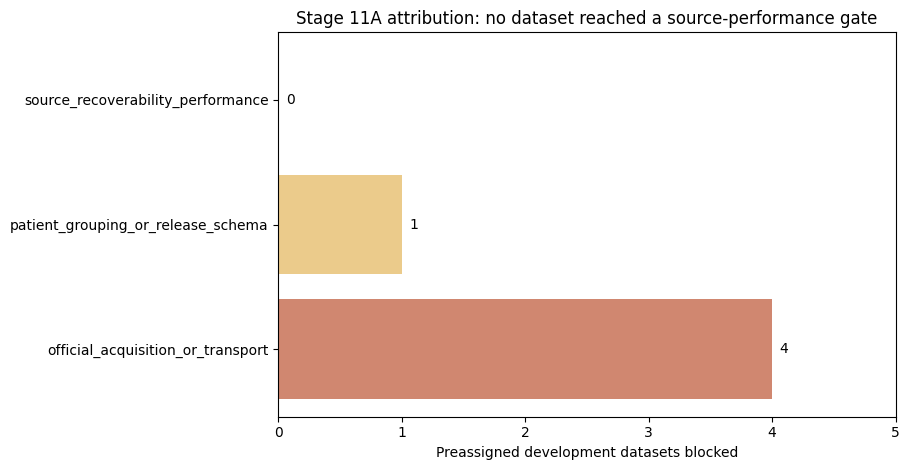


================ STAGE 11A HOLD AND UNAVAILABLE CAUSE AUDIT COMPLETE ================
Datasets audited / true model failures: 5 / 0
Repairable now / conditional / provider-access hold: 0 / 1 / 4
Locked-blind assets touched: False
Images / labels downloaded: False / False
Stage 12 / DDO2 fit / blind validation authorised: False / False / False
Decision: COMPLETE_STAGE11A_CAUSE_AUDIT_AUTHORISE_PREASSIGNED_DEVELOPMENT_ONLY_STAGE11B_REPAIR_HOLD_STAGE12_DDO2_AND_BLIND_VALIDATION
Protocol seal: e8196fcdb9c05c5b04e9bbf8ac3b520991e51114d684ef3484b36c5fbad1cd44
Cause classification hash: 1303c704d20f57ed9a05be03e0525a34c5d40624bffdece85dccb5077d99ca2d
Action registry hash: 8738b3f470e33a8de28cca1612e9595608660d6c05f1eef7e16f6f0a6b0c452b
Final record hash: 9858f91de0e78863281c74488f1002641d2d968de319fb3f239c406e26c69114
Actual Stage 11A bytes: 88054
Next step: BUILD_STAGE11B_PROTOCOL_CONFORMANT_REACQUISITION_AND_PATIENT_GROUPING_REPAIR_FOR_PREASSIGNED_DEVELOPMENT_DATASETS_ONLY


In [7]:
# @title 11A-6. Seal the cause audit, report, figure, output manifest, final record, and replay state
import matplotlib.pyplot as plt

if REPLAY_MODE:
    final_record = verify_self_hashed_json(FINAL_RECORD_PATH, "final_record_sha256")
    output_manifest = pd.read_csv(OUTPUT_MANIFEST_PATH)
    for item in output_manifest.itertuples(index=False):
        path = PROJECT_ROOT / str(item.relative_path)
        assert path.is_file() and path.stat().st_size == int(item.size_bytes) and sha256_file(path) == str(item.sha256)
    actual_stage11a_bytes = sum(path.stat().st_size for path in STAGE11A_ROOT.rglob("*") if path.is_file())
else:
    repairable_now = int(cause_classification["repairability"].str.startswith("REPAIRABLE").sum())
    conditional_repair = int(cause_classification["repairability"].str.startswith("CONDITIONAL").sum())
    provider_hold = int(len(cause_classification) - repairable_now - conditional_repair)
    any_repair_path = bool(repairable_now + conditional_repair > 0)
    decision = (
        "COMPLETE_STAGE11A_CAUSE_AUDIT_AUTHORISE_PREASSIGNED_DEVELOPMENT_ONLY_STAGE11B_REPAIR_HOLD_STAGE12_DDO2_AND_BLIND_VALIDATION"
        if any_repair_path else
        "COMPLETE_STAGE11A_CAUSE_AUDIT_NO_CONFIRMED_REPAIR_ROUTE_HOLD_STAGE11_STAGE12_DDO2_AND_BLIND_VALIDATION"
    )
    next_step = (
        "BUILD_STAGE11B_PROTOCOL_CONFORMANT_REACQUISITION_AND_PATIENT_GROUPING_REPAIR_FOR_PREASSIGNED_DEVELOPMENT_DATASETS_ONLY"
        if any_repair_path else
        "HOLD_AND_REVIEW_OFFICIAL_PROVIDER_ACCESS_WITHOUT_SUBSTITUTION_OR_BLIND_ACCESS"
    )

    plot = gate_attribution.copy()
    fig, ax = plt.subplots(figsize=(9.2, 4.8))
    colors = ["#d08770", "#ebcb8b", "#5e81ac"]
    ax.barh(plot["gate"], plot["datasets_blocked"], color=colors)
    ax.set_xlim(0, 5)
    ax.set_xlabel("Preassigned development datasets blocked")
    ax.set_title("Stage 11A attribution: no dataset reached a source-performance gate")
    for index, value in enumerate(plot["datasets_blocked"]):
        ax.text(value + 0.06, index, str(int(value)), va="center")
    fig.tight_layout()
    fig.savefig(FIGURE_PATH, dpi=180, bbox_inches="tight")
    plt.show()

    report_rows = []
    for row in cause_classification.itertuples(index=False):
        report_rows.append(f"| {row.dataset_id} | {row.primary_cause_class} | {row.repairability} | {row.true_source_performance_failure_observed} |")
    report_table = "\n".join(report_rows)
    report = f"""# Stage 11A — HOLD and Unavailable Cause Audit Report

## Decision

`{decision}`

## Parent and scope

- Stage 10 final record: `{EXPECTED_STAGE10_FINAL_HASH}`
- Stage 11 final record: `{EXPECTED_STAGE11_FINAL_HASH}`
- Stage 11 protocol seal: `{EXPECTED_STAGE11_PROTOCOL_SEAL}`
- Stage 11A protocol seal: `{protocol_seal['seal_sha256']}`
- Scope: five preassigned development datasets only. Three locked-blind datasets remained untouched.

## Answer to the audit question

Stage 11 produced **zero genuine source-recoverability performance failures**. No dataset had both a fitted frozen source axis and recorded OOF/held-out performance evidence. The observed outcome was caused upstream by access/transport and patient-grouping governance gates.

| Dataset | Primary cause | Repairability | Genuine model failure |
|---|---|---|---:|
{report_table}

## BUS-BRA reconciliation

The Stage 11 manifest contains {len(busbra_manifest)} images, while the official release states {official_expected_patients} patients. The released filenames can be parsed without loss into {candidate_groups} numeric prefixes, matching the official patient count exactly; {multi_image_candidate_groups} candidate groups contain two images and no candidate group mixes benign/malignant labels. This is strong release-consistency evidence, but Stage 11A does **not** promote the inferred prefix to a proven patient identifier. Stage 11B must corroborate the rule from released documentation or author code before rebuilding a patient-grouped manifest.

## Boundaries retained

- No image, archive, label, embedding, source axis, transfer edge, DDO2 coefficient, or blind result was produced.
- No dataset role was changed and no substitute dataset was introduced.
- Metadata probes were restricted to official provider routes for the five development datasets.
- Any licence difference is retained as provenance drift requiring reconciliation; the Stage 10 registry is not silently rewritten.
- Stage 12 remains blocked. Stage 11B may only repair transport/schema/grouping for the same preassigned development datasets.

## Next step

`{next_step}`
"""
    write_immutable_text(REPORT_PATH, report)

    tracked_files = [
        PROTOCOL_SEAL_PATH, PARENT_COMMITMENT_PATH, INHERITED_STATUS_PATH, PARENT_FILE_AUDIT_PATH,
        PROBE_LOG_PATH, BUSBRA_GROUPING_PATH, CAUSE_CLASSIFICATION_PATH, GATE_ATTRIBUTION_PATH,
        ACTION_REGISTRY_PATH, VALIDITY_PATH, REPORT_PATH, FIGURE_PATH,
    ]
    output_manifest = pd.DataFrame([
        {"relative_path": str(path.relative_to(PROJECT_ROOT)), "size_bytes": path.stat().st_size, "sha256": sha256_file(path)}
        for path in sorted(set(tracked_files), key=lambda item: str(item))
    ])
    write_immutable_csv(OUTPUT_MANIFEST_PATH, output_manifest)
    output_manifest_hash = sha256_file(OUTPUT_MANIFEST_PATH)
    tracked_bytes = int(output_manifest["size_bytes"].sum() + OUTPUT_MANIFEST_PATH.stat().st_size)
    assert tracked_bytes <= MAXIMUM_NEW_STAGE11A_BYTES

    final_record = {
        "stage": "Stage11A",
        "decision": decision,
        "scope": "HOLD_AND_UNAVAILABLE_CAUSE_AUDIT_ONLY_NO_MODEL_OR_BLIND_ACTION",
        "parent_stage10_final_record_sha256": EXPECTED_STAGE10_FINAL_HASH,
        "parent_stage10_protocol_seal_sha256": EXPECTED_STAGE10_PROTOCOL_SEAL,
        "parent_role_registry_sha256": EXPECTED_ROLE_REGISTRY_HASH,
        "parent_stage11_final_record_sha256": EXPECTED_STAGE11_FINAL_HASH,
        "parent_stage11_protocol_seal_sha256": EXPECTED_STAGE11_PROTOCOL_SEAL,
        "stage11a_protocol_seal_sha256": protocol_seal["seal_sha256"],
        "notebook_source_sha256": notebook_source_hash,
        "datasets_audited": len(cause_classification),
        "true_source_performance_failures_observed": int(cause_classification["true_source_performance_failure_observed"].sum()),
        "repairable_now": repairable_now,
        "conditional_repair_candidates": conditional_repair,
        "provider_or_access_holds": provider_hold,
        "cause_classification_sha256": sha256_file(CAUSE_CLASSIFICATION_PATH),
        "remediation_action_registry_sha256": sha256_file(ACTION_REGISTRY_PATH),
        "official_metadata_probe_log_sha256": sha256_file(PROBE_LOG_PATH),
        "busbra_grouping_audit_sha256": sha256_file(BUSBRA_GROUPING_PATH),
        "independent_validity_checks_sha256": sha256_file(VALIDITY_PATH),
        "output_integrity_manifest_sha256": output_manifest_hash,
        "tracked_stage11a_output_bytes_excluding_runtime_and_final_record": tracked_bytes,
        "maximum_new_stage11a_bytes": MAXIMUM_NEW_STAGE11A_BYTES,
        "locked_blind_assets_touched": False,
        "images_downloaded": False,
        "labels_downloaded": False,
        "embeddings_rebuilt": False,
        "source_axes_fitted": False,
        "cross_domain_edges_evaluated": False,
        "ddo2_coefficients_fitted": False,
        "stage12_authorised": False,
        "blind_validation_performed": False,
        "roles_changed": False,
        "datasets_substituted": False,
        "next_step": next_step,
        "completed_utc": utc_now(),
    }
    final_record["final_record_sha256"] = sha256_json(final_record)
    write_immutable_json(FINAL_RECORD_PATH, final_record)
    runtime_state = {
        "stage11a_complete": True,
        "decision": decision,
        "final_record_sha256": final_record["final_record_sha256"],
        "locked_blind_assets_touched": False,
        "images_downloaded": False,
        "labels_downloaded": False,
        "stage12_authorised": False,
        "ddo2_coefficients_fitted": False,
        "blind_validation_performed": False,
        "last_updated_utc": utc_now(),
    }
    atomic_json(RUNTIME_STATE_PATH, runtime_state)
    actual_stage11a_bytes = sum(path.stat().st_size for path in STAGE11A_ROOT.rglob("*") if path.is_file())

print("\n================ STAGE 11A HOLD AND UNAVAILABLE CAUSE AUDIT COMPLETE ================")
print("Datasets audited / true model failures:", final_record["datasets_audited"], "/", final_record["true_source_performance_failures_observed"])
print("Repairable now / conditional / provider-access hold:", final_record["repairable_now"], "/", final_record["conditional_repair_candidates"], "/", final_record["provider_or_access_holds"])
print("Locked-blind assets touched:", final_record["locked_blind_assets_touched"])
print("Images / labels downloaded:", final_record["images_downloaded"], "/", final_record["labels_downloaded"])
print("Stage 12 / DDO2 fit / blind validation authorised:", final_record["stage12_authorised"], "/", final_record["ddo2_coefficients_fitted"], "/", final_record["blind_validation_performed"])
print("Decision:", final_record["decision"])
print("Protocol seal:", final_record["stage11a_protocol_seal_sha256"])
print("Cause classification hash:", final_record["cause_classification_sha256"])
print("Action registry hash:", final_record["remediation_action_registry_sha256"])
print("Final record hash:", final_record["final_record_sha256"])
print("Actual Stage 11A bytes:", actual_stage11a_bytes)
print("Next step:", final_record["next_step"])
